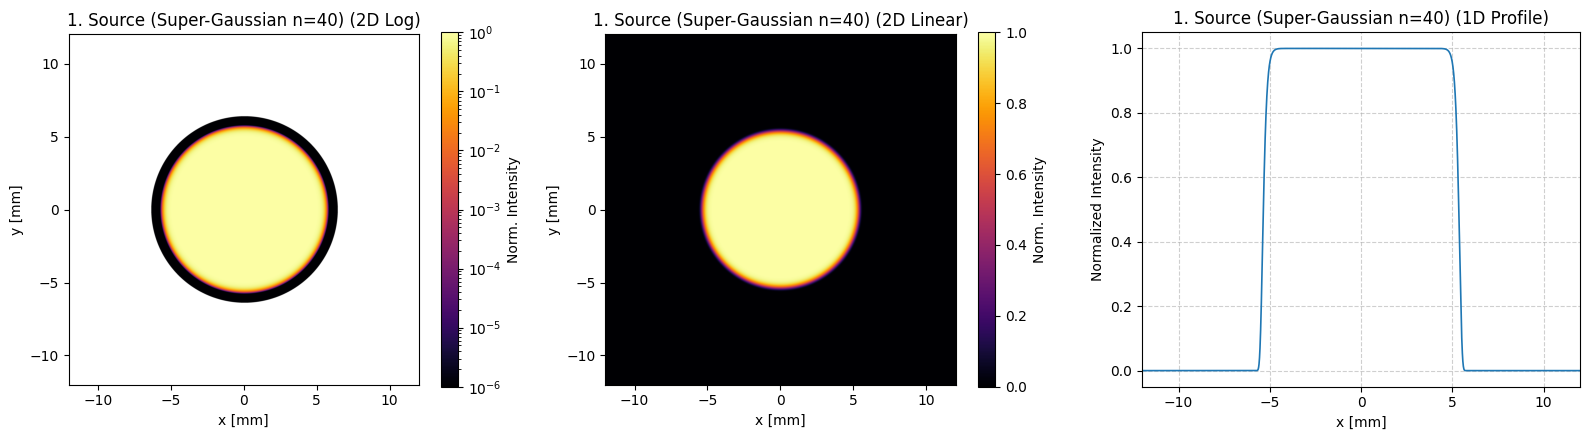

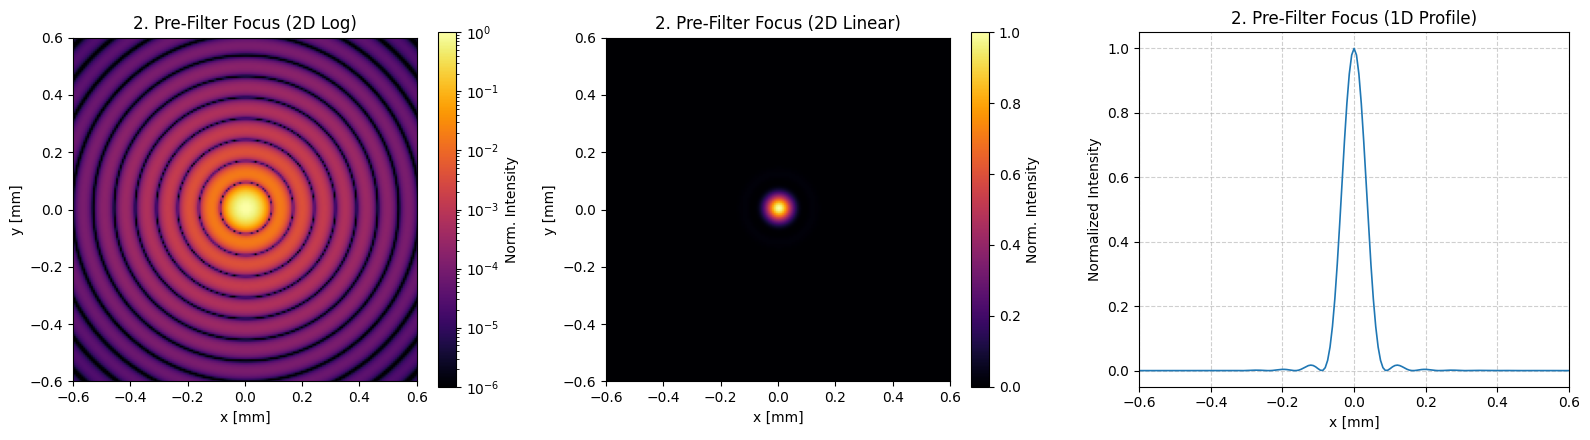

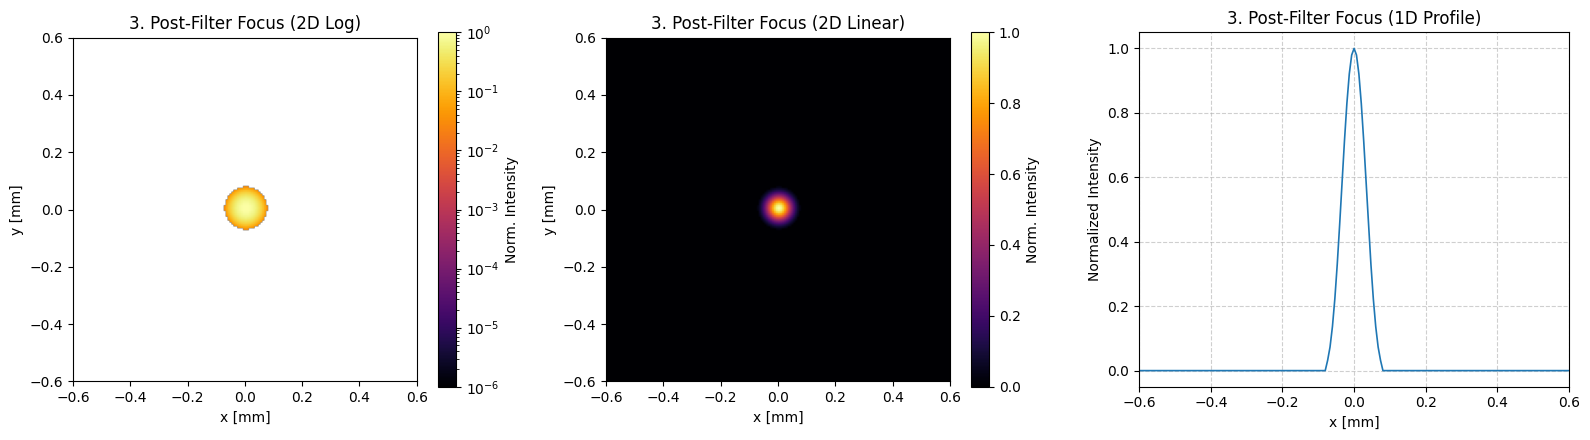

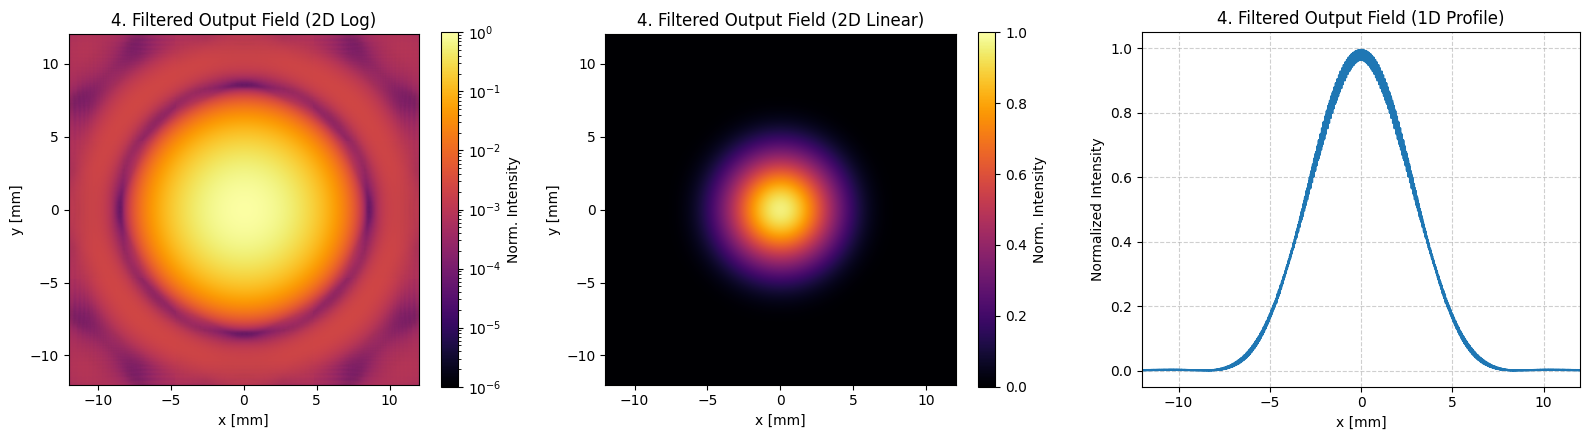

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import struct
import os

# ==============================================================
# 0) SOURCE SWITCH
# ==============================================================
SOURCE_MODE = "supergauss"   # "supergauss" oder "wcf"
WCF_FILENAME = "BeamProfile1.wcf"
SUPERGAUSS_ORDER = 40

# ==============================================================
# 1) Physical Parameters & Grid Setup
# ==============================================================
wavelength = 800e-9         # Wavelength [m]
beam_diameter = 11e-3       # Initial Beam Diameter [m]
pinhole_diameter = 150e-6   # Pinhole Diameter [m]
f1, f2 = 1.0, 1.0           # Focal lengths of Lens 1 and Lens 2 [m]

# Numerical Grid
N = 4096                    # Grid points per dimension
L = 2.5 * beam_diameter     # Total side length of the simulation window [m]
dx = L / N                  # Spatial resolution (pixel size)
x = (np.arange(N) - N/2) * dx
X, Y = np.meshgrid(x, x)
k = 2 * np.pi / wavelength  # Wave number

# ==============================================================
# 2) Optics + Propagation
# ==============================================================
def apply_lens(U, f):
    """Applies a quadratic phase shift representing a thin lens."""
    return U * np.exp(-1j * k / (2 * f) * (X**2 + Y**2))

def apply_pinhole(U, diameter):
    """Applies a circular amplitude mask (spatial filter) in the CURRENT PLANE."""
    mask = (np.sqrt(X**2 + Y**2) <= (diameter / 2)).astype(np.complex128)
    return U * mask

def propagate_asm(U0, z):
    """Propagates the field U0 over distance z using the Angular Spectrum Method."""
    fx = np.fft.fftfreq(N, d=dx)
    fy = np.fft.fftfreq(N, d=dx)
    FX, FY = np.meshgrid(fx, fy)

    kz = np.sqrt((k**2 - (2*np.pi*FX)**2 - (2*np.pi*FY)**2).astype(np.complex128))
    H = np.exp(1j * kz * z)
    return np.fft.ifft2(np.fft.fft2(U0) * H)

# ==============================================================
# 3) WCF Loader (frames like your other program) + resampling
# ==============================================================
def read_wcf_frames(filepath):
    frames = []
    FILE_HEADER  = 5592
    FRAME_HEADER = 944

    with open(filepath, "rb") as fobj:
        fobj.seek(FILE_HEADER)
        expected_w = None
        expected_h = None

        while True:
            header = fobj.read(FRAME_HEADER)
            if len(header) < FRAME_HEADER:
                break

            w = struct.unpack_from("<I", header, 20)[0]
            h = struct.unpack_from("<I", header, 24)[0]

            if expected_w is None:
                expected_w, expected_h = w, h

            # skip frames with different resolution
            if w != expected_w or h != expected_h:
                fobj.seek(w*h*2, 1)
                continue

            data = fobj.read(w*h*2)
            if len(data) < w*h*2:
                break

            frames.append(np.frombuffer(data, dtype=np.uint16).reshape((h, w)))

    return np.array(frames)

def extract_2d_profile_from_wcf(filename):
    frames = read_wcf_frames(filename)
    if frames.size == 0:
        raise RuntimeError("Keine gültigen Frames in WCF-Datei!")

    avg = np.mean(frames, axis=0).astype(np.float64)
    return avg

def resample_bilinear(img, new_h, new_w):
    """NumPy-only bilinear resampling: (h,w)->(new_h,new_w)."""
    h, w = img.shape
    if (h, w) == (new_h, new_w):
        return img.copy()

    yy = np.linspace(0, h - 1, new_h)
    xx = np.linspace(0, w - 1, new_w)

    x0 = np.floor(xx).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1)
    y0 = np.floor(yy).astype(int)
    y1 = np.clip(y0 + 1, 0, h - 1)

    wx = (xx - x0)[None, :]
    wy = (yy - y0)[:, None]

    Ia = img[y0[:, None], x0[None, :]]
    Ib = img[y0[:, None], x1[None, :]]
    Ic = img[y1[:, None], x0[None, :]]
    Id = img[y1[:, None], x1[None, :]]

    return (1 - wy) * ((1 - wx) * Ia + wx * Ib) + wy * ((1 - wx) * Ic + wx * Id)

def make_source_from_wcf(filename):
    """Build complex source field from measured WCF intensity (no hard mask)."""
    if not os.path.exists(filename):
        raise FileNotFoundError(f"{filename} nicht gefunden!")

    Iraw = extract_2d_profile_from_wcf(filename)  # float, shape (h,w)
    Iraw = Iraw.astype(np.float64)

    # Background estimate from border (robust)
    edge = max(10, int(0.03 * min(Iraw.shape)))  # ~3% of size
    border = np.concatenate([
        Iraw[:edge, :].ravel(),
        Iraw[-edge:, :].ravel(),
        Iraw[:, :edge].ravel(),
        Iraw[:, -edge:].ravel(),
    ])
    bg = np.median(border)

    I = Iraw - bg
    I[I < 0] = 0.0

    # Normalize to peak
    peak = I.max()
    if peak > 0:
        I /= peak

    # Resample to simulation grid if needed
    if I.shape != (N, N):
        I = resample_bilinear(I, N, N)

    # Intensity -> field amplitude, phase assumed flat
    U = np.sqrt(I).astype(np.complex128)
    return U

def make_source_supergauss(order=40):
    R = np.sqrt(X**2 + Y**2)
    U = np.exp(-(R / (beam_diameter/2))**order)
    return U.astype(np.complex128)

def make_source():
    if SOURCE_MODE.lower() in ("wcf", "beamprofile", "real"):
        return make_source_from_wcf(WCF_FILENAME)
    elif SOURCE_MODE.lower() in ("supergauss", "sg"):
        return make_source_supergauss(SUPERGAUSS_ORDER)
    else:
        raise ValueError("SOURCE_MODE muss 'supergauss' oder 'wcf' sein.")

# ==============================================================
# 4) 4f-System Simulation Stages
# ==============================================================
U_start = make_source()

U_lens1_applied = apply_lens(U_start, f1)
U_focus_in = propagate_asm(U_lens1_applied, f1)

U_focus_out = apply_pinhole(U_focus_in, pinhole_diameter)

U_to_lens2 = propagate_asm(U_focus_out, f2)
U_final = propagate_asm(apply_lens(U_to_lens2, f2), f2)

# ==============================================================
# 5) Data Visualization
# ==============================================================
source_name = "WCF Profile" if SOURCE_MODE.lower() in ("wcf", "beamprofile", "real") else f"Super-Gaussian n={SUPERGAUSS_ORDER}"

stations = [
    (U_start,  f"1. Source ({source_name})", 12.0),
    (U_focus_in,  "2. Pre-Filter Focus",     0.6),
    (U_focus_out, "3. Post-Filter Focus",    0.6),
    (U_final,     "4. Filtered Output Field",12.0),
]

mid_index = N // 2
x_axis_mm = x * 1e3
extent = [-L/2*1e3, L/2*1e3, -L/2*1e3, L/2*1e3]

for U, title, zoom_mm in stations:
    intensity = np.abs(U)**2
    intensity /= intensity.max() if intensity.max() > 0 else 1

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # --- Column 1: 2D Logarithmic Intensity ---
    ax2d_log = axes[0]
    im_log = ax2d_log.imshow(intensity, extent=extent, origin="lower", cmap='inferno',
                             norm=LogNorm(vmin=1e-6, vmax=1))
    ax2d_log.set_xlim(-zoom_mm, zoom_mm)
    ax2d_log.set_ylim(-zoom_mm, zoom_mm)
    ax2d_log.set_title(f"{title} (2D Log)")
    ax2d_log.set_xlabel("x [mm]")
    ax2d_log.set_ylabel("y [mm]")
    plt.colorbar(im_log, ax=ax2d_log, label="Norm. Intensity")

    # --- Column 2: 2D Linear Intensity ---
    ax2d_lin = axes[1]
    im_lin = ax2d_lin.imshow(intensity, extent=extent, origin="lower", cmap='inferno',
                             vmin=0, vmax=1)
    ax2d_lin.set_xlim(-zoom_mm, zoom_mm)
    ax2d_lin.set_ylim(-zoom_mm, zoom_mm)
    ax2d_lin.set_title(f"{title} (2D Linear)")
    ax2d_lin.set_xlabel("x [mm]")
    ax2d_lin.set_ylabel("y [mm]")
    plt.colorbar(im_lin, ax=ax2d_lin, label="Norm. Intensity")

    # --- Column 3: 1D Profile (Linear) ---
    ax1d = axes[2]
    ax1d.plot(x_axis_mm, intensity[mid_index, :], linewidth=1.2)
    ax1d.set_xlim(-zoom_mm, zoom_mm)
    ax1d.set_ylim(-0.05, 1.05)
    ax1d.set_title(f"{title} (1D Profile)")
    ax1d.set_xlabel("x [mm]")
    ax1d.set_ylabel("Normalized Intensity")
    ax1d.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

